# Erdos Institute Summer 2026 Project
## Sustainability of US cities: air pollution and climate risk

This project attempts to answer the following:

&#9989; **<font color=blue>QUESTION:** <font color=blue> In which county should someone aim to live in, for the next 20 years? 

We will try to determine which U.S. counties/cities are the most environmentally, economically, and socially sustainable using sustainability metrics from the [United Nations Sustainable Development Goals](https://sdgs.un.org/goals). 

---
This notebook will show some exploratory data analysis along the theme of air pollution and climate risk.

Our analysis is restricted to counties and county equivalents within the 50 U.S. states and the District of Columbia. U.S. territories, including Puerto Rico, Guam, American Samoa, the U.S. Virgin Islands, and the Northern Mariana Islands, were excluded because several FEMA National Risk Index variables are not reported for these jurisdictions. County-level environmental indicators were derived from census tract data using population-weighted averages, with tract populations (ACSTOTPOP) serving as weights. This approach estimates the average environmental exposure experienced by county residents while accounting for differences in tract population size. County population was obtained by summing tract populations. Thirty-five county equivalents (30 in Alaska and 5 in Hawaii) lacked EPA estimates for PM₂.₅ and ozone and will be excluded from subsequent analyses. These missing values reflect unavailable source data rather than data processing errors or random missingness.

---

### Import and clean dataset

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [41]:
df=pd.read_csv("../data/master_pollution_data.csv")

In [42]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3154 entries, 0 to 3153
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       3154 non-null   int64  
 1   FIPS                             3154 non-null   int64  
 2   County                           3142 non-null   object 
 3   State                            3142 non-null   object 
 4   Population                       3134 non-null   float64
 5   PM25                             3099 non-null   float64
 6   OZONE                            3099 non-null   float64
 7   NO2                              3134 non-null   float64
 8   DSLPM                            3104 non-null   float64
 9   PTRAF                            3134 non-null   float64
 10  RSEI_AIR                         3134 non-null   float64
 11  AREA                             3134 non-null   float64
 12  RISK_SCORE          

,Unnamed: 0,FIPS,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,AREA,...,Reproductive HI,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI
count,3154.000000,3154.000000,3.134000e+03,3099.000000,3099.000000,3134.000000,3104.000000,3.134000e+03,3134.000000,3134.000000,...,3142.000000,3142.000000,3.142000e+03,3.142000e+03,3.142000e+03,3142.000000,3.142000e+03,3.142000e+03,3142.000000,3142.000000
mean,1576.500000,30327.203868,1.044903e+05,7.383072,57.112985,5.214448,0.085516,2.818769e+05,2815.697822,1223.195276,...,0.031483,0.004152,1.731581e-06,1.614128e-06,7.912815e-07,0.013250,1.203299e-04,9.099938e-05,0.003596,0.000470
std,910.625701,15207.603529,3.336280e+05,1.610567,5.267317,1.965111,0.059260,6.956545e+05,15855.472883,3843.258630,...,0.017870,0.006474,2.332577e-05,9.176807e-06,2.243106e-06,0.008898,7.004115e-04,1.330125e-03,0.005834,0.011772
min,0.000000,0.000000,5.000000e+01,3.551251,39.463545,0.059275,0.000787,0.000000e+00,0.000000,2.067115,...,0.004561,0.000003,0.000000e+00,1.867550e-09,0.000000e+00,0.001651,0.000000e+00,0.000000e+00,0.000003,0.000007
25%,788.250000,18167.500000,1.080500e+04,6.363770,53.152271,3.844247,0.048165,2.365357e+04,16.855117,450.271381,...,0.018752,0.001393,3.088640e-11,1.570971e-07,2.222046e-08,0.008450,2.158528e-07,0.000000e+00,0.001019,0.000055
50%,1576.500000,29172.000000,2.560100e+04,7.396356,56.163328,4.961854,0.071964,8.214124e+04,175.098998,658.139159,...,0.029243,0.002738,2.656325e-10,4.329765e-07,1.420686e-07,0.011586,1.108332e-05,0.000000e+00,0.002342,0.000085
75%,2364.750000,45078.500000,6.760675e+04,8.300312,60.449698,6.310764,0.106400,2.361184e+05,951.371442,999.828696,...,0.040285,0.004828,1.393743e-08,1.178709e-06,6.894668e-07,0.015977,7.688780e-05,3.027468e-08,0.004058,0.000124
max,3153.000000,56045.000000,9.936690e+06,20.766112,100.897911,18.344521,0.748876,1.453606e+07,407008.363420,149363.640223,...,0.194820,0.168222,8.146454e-04,3.625240e-04,4.579961e-05,0.179320,3.000488e-02,5.308087e-02,0.113783,0.479720


In [111]:
# Identifier variables
id_cols = [
    "FIPS",
    "County",
    "State",
    "Population"
]

# EPA variables
epa_cols = [
    "PM25",
    "OZONE",
    "NO2",
    "DSLPM",
    "PTRAF",
    "RSEI_AIR"
]

# NRI variables
nri_cols = [
    "RISK_SCORE",
    "EAL_SCORE",
    "SOVI_SCORE",
    "RESL_SCORE"
]

# Cancer variable
cancer_cols = [
    "Total Cancer Risk (per million)"
]

# Hazard Index variables
hi_cols = [
    "Respiratory HI",
    "Neurological HI",
    "Liver HI",
    "Developmental HI",
    "Reproductive HI",
    "Kidney HI",
    "Ocular HI",
    "Endocrine HI",
    "Hematological HI",
    "Immunological HI",
    "Skeletal HI",
    "Spleen HI",
    "Thyroid HI",
    "Whole Body HI"
]

In [46]:
df["FIPS"].nunique(), len(df)

(3154, 3154)

In [47]:
# Check for missing data:
df.isna().sum().sort_values(ascending=False)

PM25                               55
OZONE                              55
DSLPM                              50
RESL_SCORE                         20
PTRAF                              20
SOVI_SCORE                         20
EAL_SCORE                          20
RISK_SCORE                         20
AREA                               20
RSEI_AIR                           20
NO2                                20
Population                         20
Reproductive HI                    12
Spleen HI                          12
Thyroid HI                         12
Skeletal HI                        12
Immunological HI                   12
Hematological HI                   12
Endocrine HI                       12
Ocular HI                          12
Kidney HI                          12
Whole Body HI                      12
Developmental HI                   12
Liver HI                           12
Neurological HI                    12
Respiratory HI                     12
Total Cancer

Check what counties are actually missing data:

In [49]:
# Number of missing values per county
df["n_missing"] = df.isna().sum(axis=1)

df["n_missing"].value_counts().sort_index()

n_missing
0     3099
2        5
3       27
12      11
20       3
29       9
Name: count, dtype: int64

In [50]:
## Why might these values be missing?
df[df["PM25"].isna()][["FIPS","County","State"]]

,FIPS,County,State
67,2013,Aleutians East,AK
68,2016,Aleutians West,AK
69,2020,Anchorage,AK
70,2050,Bethel,AK
71,2060,Bristol Bay,AK
72,2068,Denali,AK
73,2070,Dillingham,AK
74,2090,Fairbanks North Star,AK
75,2100,Haines,AK
76,2110,Juneau,AK


**Remark**

55 county-equivalent observations (less than 2% of the dataset) contained no environmental or climate measurements, primarily due to obsolete county definitions or unavailable source data. These include Alaska boroughs and counties with too little monitoring data, obsolete county definitions, special administrative areas, or non-standard county equivalents. These observations were excluded from the analysis.

In [51]:
df=df.dropna()

In [52]:
(df.isna().mean() * 100).sort_values(ascending=False)

Unnamed: 0                         0.0
FIPS                               0.0
Whole Body HI                      0.0
Thyroid HI                         0.0
Spleen HI                          0.0
Skeletal HI                        0.0
Immunological HI                   0.0
Hematological HI                   0.0
Endocrine HI                       0.0
Ocular HI                          0.0
Kidney HI                          0.0
Reproductive HI                    0.0
Developmental HI                   0.0
Liver HI                           0.0
Neurological HI                    0.0
Respiratory HI                     0.0
Total Cancer Risk (per million)    0.0
RESL_SCORE                         0.0
SOVI_SCORE                         0.0
EAL_SCORE                          0.0
RISK_SCORE                         0.0
AREA                               0.0
RSEI_AIR                           0.0
PTRAF                              0.0
DSLPM                              0.0
NO2                      

---
### EPA Analysis

In [53]:
df[epa_cols].describe()

,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR
count,3099.000000,3099.000000,3099.000000,3099.000000,3.099000e+03,3099.000000
mean,7.383072,57.112985,5.251838,0.085590,2.831042e+05,2846.821158
std,1.610567,5.267317,1.928982,0.059243,6.973611e+05,15942.058982
min,3.551251,39.463545,0.959139,0.004677,0.000000e+00,0.000000
25%,6.363770,53.152271,3.866692,0.048299,2.407494e+04,18.155130
50%,7.396356,56.163328,4.978770,0.072005,8.278367e+04,180.533008
75%,8.300312,60.449698,6.337396,0.106400,2.374079e+05,974.816749
max,20.766112,100.897911,18.344521,0.748876,1.453606e+07,407008.363420


In [54]:
# Top counites for PM25:
df.sort_values("PM25").head(10)
df.sort_values("PM25", ascending=False).head(10)

,Unnamed: 0,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,...,Kidney HI,Ocular HI,Endocrine HI,Hematological HI,Immunological HI,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI,n_missing
245,245,6107,Tulare,CA,473446.0,20.766112,85.393045,8.884714,0.301770,8.544028e+05,...,0.002915,3.214547e-08,1.710527e-06,4.179876e-07,0.014001,2.100606e-03,2.505401e-10,0.005308,0.028658,0
217,217,6051,Mono,CA,13219.0,19.218878,68.207364,7.187557,0.014548,1.082866e+05,...,0.000131,5.585942e-12,2.552811e-08,6.176223e-09,0.002588,0.000000e+00,0.000000e+00,0.000335,0.000146,0
201,201,6019,Fresno,CA,1008280.0,18.996997,81.646436,8.098217,0.381444,1.837905e+06,...,0.004089,8.083282e-08,2.613083e-06,6.714588e-07,0.017629,8.191978e-05,1.703529e-09,0.007718,0.070462,0
207,207,6031,Kings,CA,152515.0,18.119941,77.704295,7.809315,0.247335,4.820815e+05,...,0.002568,8.292251e-09,1.090643e-06,4.184892e-07,0.011591,2.589603e-04,4.286396e-11,0.002556,0.014850,0
211,211,6039,Madera,CA,157243.0,17.771910,77.632743,7.246562,0.276208,6.958115e+05,...,0.002196,1.632268e-09,1.212627e-06,2.493083e-07,0.012810,0.000000e+00,9.879012e-11,0.007306,0.028652,0
2219,2219,41005,Clackamas,OR,420925.0,17.224415,56.873427,6.282849,0.256859,1.209257e+06,...,0.015811,2.779611e-08,3.356356e-06,2.983304e-06,0.035110,9.624445e-05,0.000000e+00,0.007005,0.000389,0
213,213,6043,Mariposa,CA,17130.0,16.618109,78.236945,3.075873,0.028793,2.780776e+04,...,0.000376,2.725389e-09,5.564291e-08,1.515875e-08,0.005149,0.000000e+00,0.000000e+00,0.000837,0.000550,0
195,195,6007,Butte,CA,213605.0,16.165953,69.257909,6.829725,0.136518,7.572261e+05,...,0.002847,2.670671e-08,1.117745e-06,2.066091e-07,0.011778,1.020262e-10,0.000000e+00,0.003788,0.001496,0
242,242,6101,Sutter,CA,99101.0,15.801055,67.409238,8.575359,0.155273,1.001485e+06,...,0.003072,2.855021e-07,1.329358e-06,2.782216e-07,0.012922,3.383741e-06,3.357032e-06,0.005102,0.000285,0
2232,2232,41031,Jefferson,OR,24659.0,15.419746,56.700444,4.276727,0.045540,9.782686e+04,...,0.000836,5.201809e-11,3.050972e-07,2.461707e-07,0.006727,3.592083e-06,0.000000e+00,0.002901,0.000445,0


In [56]:
# Top states for PM 25
df.groupby("State")["PM25"].mean().sort_values()

State
WY     4.622432
ME     5.042371
NH     5.240827
SD     5.302724
NM     5.303934
ND     5.330814
MT     5.604496
VT     5.681670
CO     5.743212
MN     5.882891
AZ     5.893609
RI     5.919713
UT     6.016926
NE     6.070143
MA     6.389744
MD     6.437320
NC     6.530184
MI     6.572600
VA     6.574807
WV     6.625794
NY     6.818929
TN     6.931960
DE     6.948954
DC     7.041643
KS     7.174608
WI     7.224370
ID     7.277389
NV     7.349487
IA     7.353082
MO     7.483919
NJ     7.518760
TX     7.593698
SC     7.597821
PA     7.654324
OH     7.732231
KY     7.833400
FL     7.836539
AR     8.058709
LA     8.076003
OK     8.346439
AL     8.354676
IN     8.388888
IL     8.476052
GA     8.520500
MS     8.528498
WA     9.574911
OR    11.506073
CA    12.320757
Name: PM25, dtype: float64

#### Correlation analysis

In [57]:
corr = df[epa_cols].corr()

<Axes: >

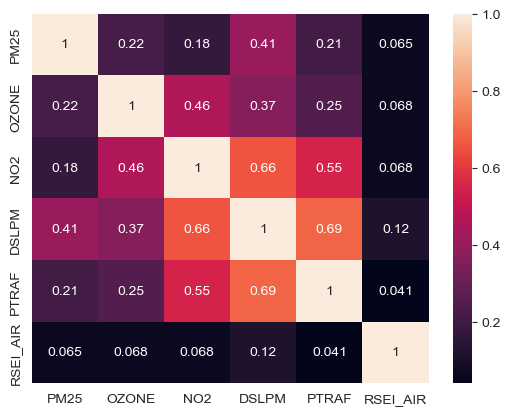

In [58]:
sns.heatmap(corr, annot=True)

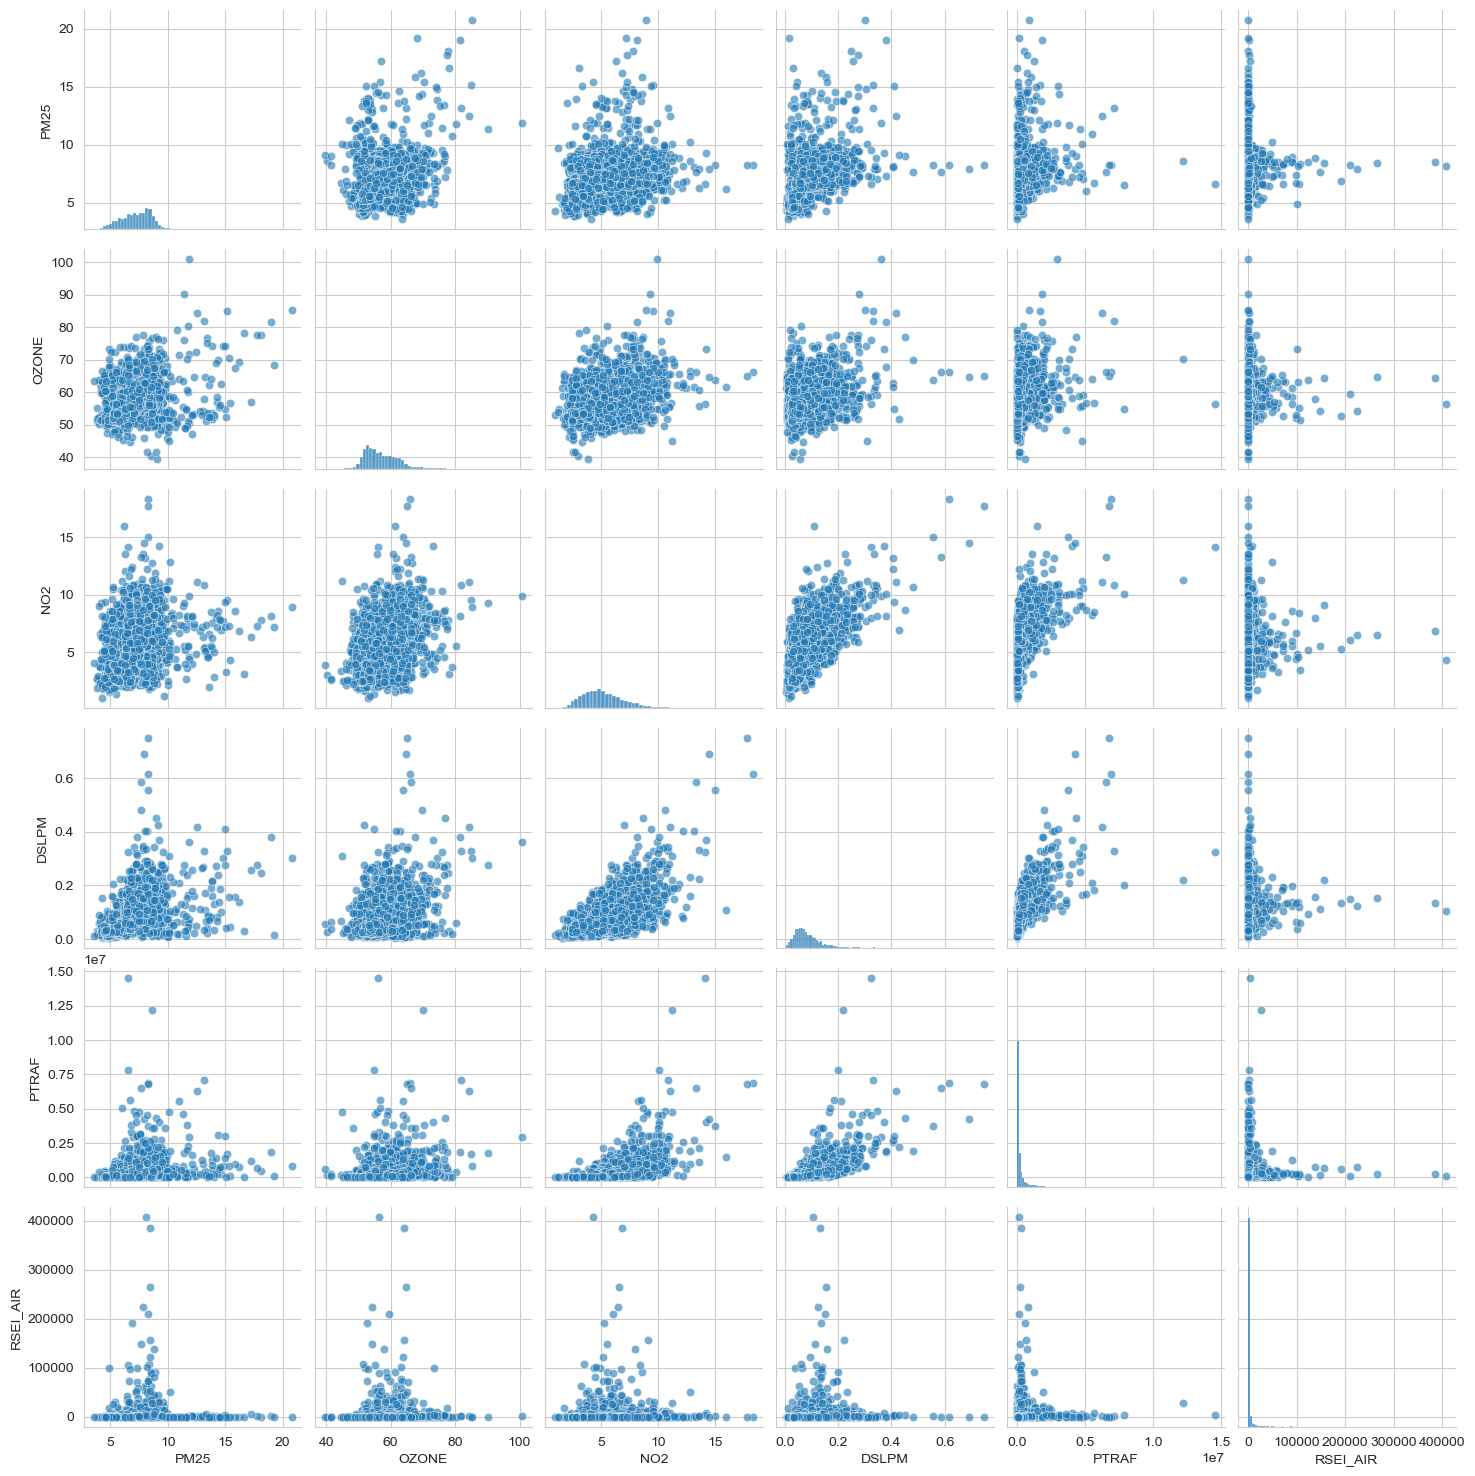

In [59]:
sns.pairplot(data = df[epa_cols],
                x_vars = epa_cols,
                y_vars = epa_cols,
                plot_kws = {'alpha':.6})

plt.show()

#### PCA on EPA data

In [60]:
pollution= df[epa_cols]

In [69]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

pollution_scaled = StandardScaler().fit_transform(pollution)

vif = pd.DataFrame({
    "Variable": pollution.columns,
    "VIF": [variance_inflation_factor(pollution_scaled, i)
            for i in range(pollution_scaled.shape[1])]
})

print(vif.sort_values("VIF", ascending=False))

   Variable       VIF
3     DSLPM  2.861717
2       NO2  2.080346
4     PTRAF  1.978505
1     OZONE  1.306031
0      PM25  1.253885
5  RSEI_AIR  1.017696


In [70]:
# Fit PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pca = PCA()
X_pca = pca.fit_transform(pollution_scaled)

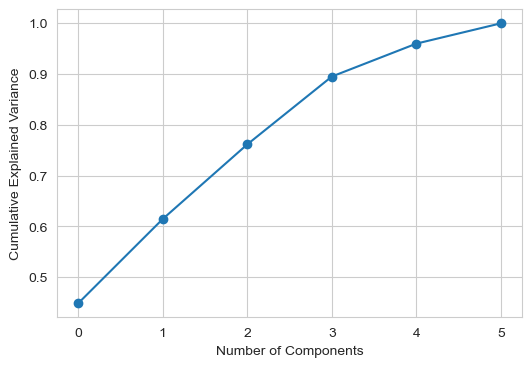

In [71]:
## Examine explained variance:

import numpy as np
import matplotlib.pyplot as plt

explained = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(explained), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [72]:
explained

array([0.44869593, 0.16600239, 0.1469264 , 0.13359416, 0.06480259,
       0.03997853])

In [73]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pollution.columns))],
    index=pollution.columns
)

print(loadings)

               PC1       PC2       PC3       PC4       PC5       PC6
PM25      0.292891  0.202565  0.897971 -0.022171  0.083136 -0.243776
OZONE     0.365212  0.015667 -0.055887  0.856218 -0.357801  0.046050
NO2       0.499651 -0.127377 -0.298536  0.085048  0.706705 -0.371935
DSLPM     0.543944 -0.021690  0.031593 -0.241385  0.074560  0.799268
PTRAF     0.475711 -0.168847 -0.180584 -0.440774 -0.599667 -0.398368
RSEI_AIR  0.094911  0.955781 -0.260368 -0.081346 -0.021816 -0.050894


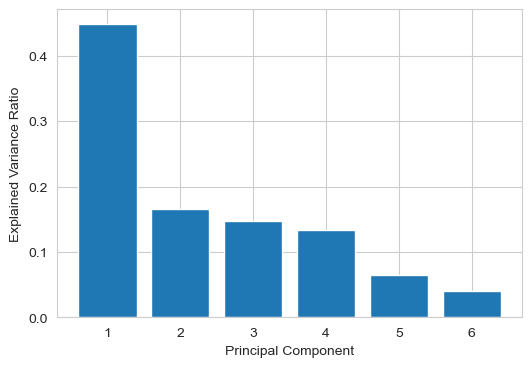

In [74]:
plt.figure(figsize=(6,4))

plt.bar(
    range(1, len(explained)+1),
    explained
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

These loadings and the above plot may be interpreted as follows:
1. PC1: Overall ambient air pollution, with a stronger influence from traffic-related pollutants.
2. PC2: Industrial toxic emissions (clearly dominated by RSEI_AIR).
3. PC3 separates regional particulate pollution from traffic pollution.
4. Together, the first three principal components explained 76.2% of the total variability.

In [76]:
# This is the dataframe with values for PC1 through PC5 for all counties in our dataset.

scores = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    index=pollution.index
)

scores = scores.join(df.loc[pollution.index, ["State", "County", "FIPS"]])
scores.head()

,PC1,PC2,PC3,PC4,PC5,PC6,State,County,FIPS
0,-0.061287,0.095952,0.953857,-1.135245,0.485228,-0.109452,AL,Autauga,1001
1,-0.383722,0.209135,1.333886,-0.377215,-0.309087,-0.011684,AL,Baldwin,1003
2,-1.015965,0.102087,0.892332,-0.557362,-0.027363,-0.318409,AL,Barbour,1005
3,-1.211106,0.331725,1.179750,-0.674954,-0.408937,0.084097,AL,Bibb,1007
4,-0.666033,0.228226,1.010997,-0.242631,-0.312345,0.202757,AL,Blount,1009


In [77]:
scores.sort_values("PC1", ascending=False).head(20)

,PC1,PC2,PC3,PC4,PC5,PC6,State,County,FIPS
1867,14.461854,-2.650331,-2.818180,-4.966632,-0.662863,2.769369,NY,New York,36061
1236,14.012223,-4.140712,-5.412479,-9.735911,-8.683835,-6.528264,MA,Suffolk,25025
1839,13.506703,-2.671923,-3.018581,-4.287513,-0.756929,0.812279,NY,Bronx,36005
3099,12.183201,-1.642182,-3.816127,-5.836252,-8.743800,-6.305281,WI,Milwaukee,55079
1877,11.605409,-2.317449,-2.481141,-4.144151,-2.392559,1.690859,NY,Queens,36081
210,11.442435,-1.295605,0.315406,-0.523200,-4.184476,-0.604360,CA,Los Angeles,6037
1860,11.289690,-1.857258,-1.893606,-3.338169,0.217867,4.101268,NY,Kings,36047
221,11.090624,-1.385078,0.484886,-1.111816,-4.855791,-2.320700,CA,Orange,6059
1791,9.798798,-1.635287,-1.710088,-2.565841,0.789532,2.449249,NJ,Hudson,34017
227,9.385645,-0.484503,0.808062,4.462910,-2.993640,1.011002,CA,San Bernardino,6071


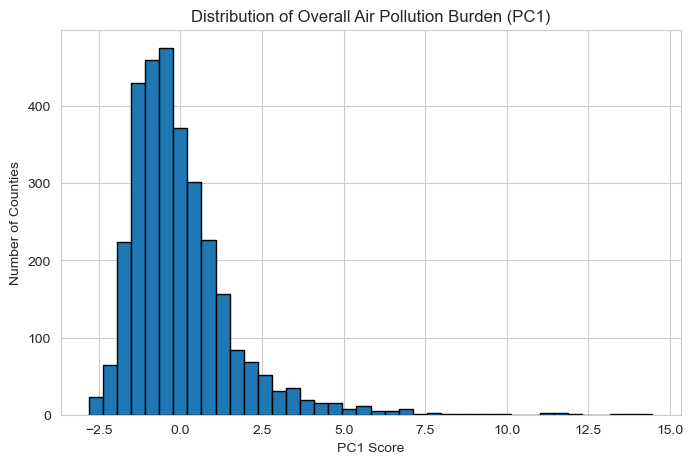

In [78]:
## Examine the disctibution of PC1: 
plt.figure(figsize=(8,5))

plt.hist(scores["PC1"], bins=40, edgecolor="black")

plt.xlabel("PC1 Score")
plt.ylabel("Number of Counties")
plt.title("Distribution of Overall Air Pollution Burden (PC1)")

plt.show()

#### Ranking EPA

We will weigh each principal component by the proportion of variance it explains, so that the composite air pollution index using normalized weights becomes: 
$$ \text{Air index} = 0.589 PC_1 + 0. 218 PC_2 + 0.193 PC_3$$

In [80]:
weights = explained[:3] / explained[:3].sum()

print(weights)

[0.58912994 0.21795825 0.19291181]


In [85]:
#Compute air pollution index
df["Air_Index"] = (
    weights[0] * scores.iloc[:, 0] +
    weights[1] * scores.iloc[:, 1] +
    weights[2] * scores.iloc[:, 2]
)

from sklearn.preprocessing import MinMaxScaler

df["Air_Index"] = MinMaxScaler((0, 100)).fit_transform(
    df[["Air_Index"]]
)

df["Air_Rank"] = df["Air_Index"].rank(
    ascending=False,
    method="min"
)

In [97]:
## Append PC, PC2 and PC3 to the master df
df["PC1"]=scores.iloc[:, 0]
df["PC2"]=scores.iloc[:, 1]
df["PC3"]=scores.iloc[:, 2]

In [98]:
df.head()

,Unnamed: 0,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,...,Skeletal HI,Spleen HI,Thyroid HI,Whole Body HI,n_missing,Air_Index,Air_Rank,PC1,PC2,PC3
0,0,1001,Autauga,AL,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,...,0.000056,2.503434e-06,0.009789,0.000187,0,22.365533,1038.0,-0.061287,0.095952,0.953857
1,1,1003,Baldwin,AL,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,...,0.000027,3.376943e-09,0.004429,0.000102,0,21.377891,1137.0,-0.383722,0.209135,1.333886
2,2,1005,Barbour,AL,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,...,0.002610,3.297103e-06,0.002180,0.000209,0,16.212978,1926.0,-1.015965,0.102087,0.892332
3,3,1007,Bibb,AL,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,...,0.000071,3.232020e-05,0.001929,0.000151,0,16.111340,1942.0,-1.211106,0.331725,1.179750
4,4,1009,Blount,AL,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,...,0.000050,2.523939e-05,0.005514,0.000144,0,18.967750,1483.0,-0.666033,0.228226,1.010997


---
### Climate risk ranking

In [115]:
nri=df[nri_cols].copy()
nri.describe()

,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
count,3099.000000,3099.000000,3099.000000,3099.000000
mean,50.009648,49.621315,50.570415,50.180350
std,28.750671,28.776724,27.915267,28.814012
min,0.031807,0.030941,10.623410,0.031807
25%,25.174936,24.737005,25.063613,25.270356
50%,50.000000,49.319307,50.031807,50.190840
75%,74.856870,74.551361,74.888677,75.079517
max,100.000000,100.000000,99.872774,100.000000


<Axes: >

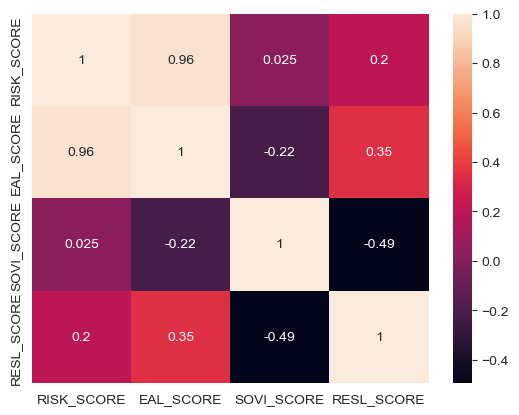

In [113]:
corr_2 = nri.corr()
sns.heatmap(corr_2, annot=True)

In [116]:
# Compute VIF:
nri_scaled = StandardScaler().fit_transform(nri)

vif_2 = pd.DataFrame({
    "Variable": nri.columns,
    "VIF": [variance_inflation_factor(nri_scaled, i)
            for i in range(nri_scaled.shape[1])]
})

print(vif_2.sort_values("VIF", ascending=False))


     Variable        VIF
1   EAL_SCORE  72.526861
0  RISK_SCORE  67.912652
2  SOVI_SCORE   4.825524
3  RESL_SCORE   1.539409


In [117]:
Y = StandardScaler().fit_transform(nri)

pca_2 = PCA()
scores = pd.DataFrame(
    pca_2.fit_transform(Y),
    columns=[f"PC{i+1}" for i in range(len(nri.columns))]
)

explained_2 = pca_2.explained_variance_ratio_

print(explained_2)

[0.54631769 0.33084    0.12110048 0.00174184]


In [118]:
loadings_2 = pd.DataFrame(
    pca_2.components_.T,
    index=nri.columns,
    columns=scores.columns
)

print(loadings_2.round(3))

              PC1    PC2    PC3    PC4
RISK_SCORE  0.588  0.426 -0.039 -0.686
EAL_SCORE   0.645  0.238 -0.153  0.709
SOVI_SCORE -0.273  0.691  0.651  0.157
RESL_SCORE  0.404 -0.533  0.743 -0.028


**Observe** From the above PCA analysis, that:
1. PC1 (54.6% variance load) is dominated by EAL_SCORE (0.645) and RISK_SCORE (0.588), indicating that this PC measures overall natural hazard risk. But both these variables are essentially the same thing, as we see from the high correlation.
2. PC2 measures social vulnerability versus community resilience, by a similar argument.
3. PC1 and PC2 explain 87.7% of the total variation in the data.

Consequently, we shall not derive another composite score for climate risk, and we will use the RISK_SCORE for ranking instead.

---
### Health risk rankings

In [119]:
health_cols = [
    "Total Cancer Risk (per million)",
    "Whole Body HI"
]

health = df[health_cols].copy()

<Axes: >

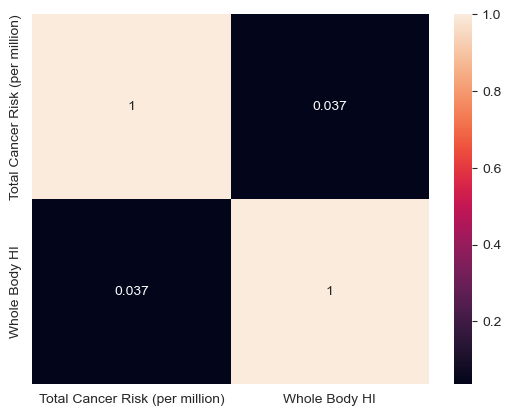

In [120]:
# Examine the correlation: 
corr_3=health.corr()
sns.heatmap(corr_3, annot=True)

In [121]:
# compute VIF: 
health_scaled = StandardScaler().fit_transform(health)

vif_health = pd.DataFrame({
    "Variable": health.columns,
    "VIF": [
        variance_inflation_factor(health_scaled, i)
        for i in range(health_scaled.shape[1])
    ]
})

print(vif_health)

                          Variable       VIF
0  Total Cancer Risk (per million)  1.001377
1                    Whole Body HI  1.001377


In [122]:
# PCA:
from sklearn.decomposition import PCA

pca_health = PCA()

health_scores = pd.DataFrame(
    pca_health.fit_transform(health_scaled),
    columns=["PC1","PC2"]
)

health_explained = pca_health.explained_variance_ratio_

print(health_explained)

[0.51853868 0.48146132]


In [123]:
loadings = pd.DataFrame(
    pca_health.components_.T,
    index=health.columns,
    columns=["PC1","PC2"]
)

print(loadings.round(3))

                                   PC1    PC2
Total Cancer Risk (per million)  0.707  0.707
Whole Body HI                    0.707 -0.707


**Remark:**
We observe that the two health variables `Total Cancer Risk (per million)` and `Whole Body HI` are almost independent and have very little collinearity. So these are measuring two different aspects of health risk. Hence, our health index will be an average of both.

In [124]:
health_z = pd.DataFrame(
    health_scaled,
    columns=health.columns
)

# HEALTH INDEX
df["Health_Index"] = (
    health_z["Total Cancer Risk (per million)"]
    + health_z["Whole Body HI"]
) / 2


In [125]:
df.head()

,Unnamed: 0,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,...,Spleen HI,Thyroid HI,Whole Body HI,n_missing,Air_Index,Air_Rank,PC1,PC2,PC3,Health_Index
0,0,1001,Autauga,AL,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,...,2.503434e-06,0.009789,0.000187,0,22.365533,1038.0,-0.061287,0.095952,0.953857,-0.033058
1,1,1003,Baldwin,AL,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,...,3.376943e-09,0.004429,0.000102,0,21.377891,1137.0,-0.383722,0.209135,1.333886,0.050787
2,2,1005,Barbour,AL,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,...,3.297103e-06,0.002180,0.000209,0,16.212978,1926.0,-1.015965,0.102087,0.892332,-0.064924
3,3,1007,Bibb,AL,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,...,3.232020e-05,0.001929,0.000151,0,16.111340,1942.0,-1.211106,0.331725,1.179750,-0.107932
4,4,1009,Blount,AL,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,...,2.523939e-05,0.005514,0.000144,0,18.967750,1483.0,-0.666033,0.228226,1.010997,-0.079511


In [128]:
df = df.drop(columns=["n_missing", "Air_Rank", 'Respiratory HI', 'Neurological HI', 'Liver HI', 'Developmental HI',
       'Reproductive HI', 'Kidney HI', 'Ocular HI', 'Endocrine HI',
       'Hematological HI', 'Immunological HI', 'Skeletal HI', 'Spleen HI',
       'Thyroid HI'])
df.head()

,Unnamed: 0,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,...,EAL_SCORE,SOVI_SCORE,RESL_SCORE,Total Cancer Risk (per million),Whole Body HI,Air_Index,PC1,PC2,PC3,Health_Index
0,0,1001,Autauga,AL,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,...,59.870050,38.040712,55.120865,641.344644,0.000187,22.365533,-0.061287,0.095952,0.953857,-0.033058
1,1,1003,Baldwin,AL,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,...,96.627475,44.243003,93.002545,1131.580093,0.000102,21.377891,-0.383722,0.209135,1.333886,0.050787
2,2,1005,Barbour,AL,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,...,30.538366,96.374046,11.164122,457.387006,0.000209,16.212978,-1.015965,0.102087,0.892332,-0.064924
3,3,1007,Bibb,AL,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,...,31.002475,75.254453,22.169211,229.922349,0.000151,16.111340,-1.211106,0.331725,1.179750,-0.107932
4,4,1009,Blount,AL,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,...,62.345297,69.338422,15.648855,391.032211,0.000144,18.967750,-0.666033,0.228226,1.010997,-0.079511


In [136]:
df.drop(columns=["Unnamed: 0"])

,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,RSEI_AIR,...,Air_Index,PC1,PC2,PC3,Health_Index,Air_Index_z,RISK_SCORE_z,Health_Index_z,Environmental_Risk_Index,Overall_Rank
0,1001,Autauga,AL,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,1649.308252,...,22.365533,-0.061287,0.095952,0.953857,-0.033058,0.167607,0.263004,-0.043454,0.129052,1092.0
1,1003,Baldwin,AL,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,522.689409,...,21.377891,-0.383722,0.209135,1.333886,0.050787,0.076292,1.625069,0.073822,0.591727,438.0
2,1005,Barbour,AL,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,152.316386,...,16.212978,-1.015965,0.102087,0.892332,-0.064924,-0.401243,-0.065617,-0.088027,-0.184963,1710.0
3,1007,Bibb,AL,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,2121.376387,...,16.111340,-1.211106,0.331725,1.179750,-0.107932,-0.410641,-0.378748,-0.148183,-0.312524,2009.0
4,1009,Blount,AL,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,1379.140438,...,18.967750,-0.666033,0.228226,1.010997,-0.079511,-0.146544,0.642523,-0.108429,0.129183,1091.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149,56037,Sweetwater,WY,42079.0,4.282689,63.228821,8.105548,0.154190,259437.481534,109.410993,...,21.934524,1.197006,-0.743815,-2.148087,NaN,0.127757,-0.674176,NaN,NaN,NaN
3150,56039,Teton,WY,23346.0,4.445018,61.689650,5.090137,0.030738,111022.830945,0.000000,...,10.500598,-0.896967,-0.454239,-1.600100,NaN,-0.929396,0.717763,NaN,NaN,NaN
3151,56041,Uinta,WY,20546.0,5.523874,66.295652,9.163653,0.095233,152795.860187,11.414990,...,23.896120,1.294805,-0.606904,-1.654506,NaN,0.309121,-1.158809,NaN,NaN,NaN
3152,56043,Washakie,WY,7725.0,4.568317,60.398357,7.284553,0.030635,66859.446596,198.414098,...,12.708413,-0.425483,-0.564868,-1.849168,NaN,-0.725267,-0.892150,NaN,NaN,NaN


---
### Overall air and environmental sustainability ranking

Our `Environmental_Risk_Index` score will be an equal weighting of the three domains: air pollution, climate risk, and health risks.

In [130]:
df[[
    "Air_Index",
    "RISK_SCORE",
    "Health_Index"
]].corr()

,Air_Index,RISK_SCORE,Health_Index
Air_Index,1.000000,0.542956,0.084024
RISK_SCORE,0.542956,1.000000,0.037635
Health_Index,0.084024,0.037635,1.000000


In [131]:
# Standardize all three scores

domain_cols = ["Air_Index", "RISK_SCORE", "Health_Index"]

df[[f"{c}_z" for c in domain_cols]] = StandardScaler().fit_transform(
    df[domain_cols]
)

In [132]:
# Compute score:
df["Environmental_Risk_Index"] = (
    df["Air_Index_z"] +
    df["RISK_SCORE_z"] +
    df["Health_Index_z"]
) / 3

In [134]:
df["Overall_Rank"] = df["Environmental_Risk_Index"].rank(
    ascending=False,
    method="min"
)

In [137]:
df.head()

,Unnamed: 0,FIPS,County,State,Population,PM25,OZONE,NO2,DSLPM,PTRAF,...,Air_Index,PC1,PC2,PC3,Health_Index,Air_Index_z,RISK_SCORE_z,Health_Index_z,Environmental_Risk_Index,Overall_Rank
0,0,1001,Autauga,AL,58761.0,8.913208,50.662299,5.173662,0.098470,307790.990536,...,22.365533,-0.061287,0.095952,0.953857,-0.033058,0.167607,0.263004,-0.043454,0.129052,1092.0
1,1,1003,Baldwin,AL,233420.0,9.175796,54.878235,3.587880,0.078929,211663.701507,...,21.377891,-0.383722,0.209135,1.333886,0.050787,0.076292,1.625069,0.073822,0.591727,438.0
2,2,1005,Barbour,AL,24877.0,8.368747,52.365743,3.833613,0.047168,92922.233960,...,16.212978,-1.015965,0.102087,0.892332,-0.064924,-0.401243,-0.065617,-0.088027,-0.184963,1710.0
3,3,1007,Bibb,AL,22251.0,8.562335,52.211148,2.595553,0.060176,48853.424324,...,16.111340,-1.211106,0.331725,1.179750,-0.107932,-0.410641,-0.378748,-0.148183,-0.312524,2009.0
4,4,1009,Blount,AL,59077.0,8.492552,55.096873,3.360859,0.077418,56869.288455,...,18.967750,-0.666033,0.228226,1.010997,-0.079511,-0.146544,0.642523,-0.108429,0.129183,1091.0


In [139]:
df.to_csv("../data/environmental_ranking.csv")